In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [ ]:
electricity_path = "C:/Users/calso/Downloads/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377.csv"
internet_path = "C:/Users/calso/Downloads/zainternet indi/API_IT.NET.USER.ZS_DS2_en_csv_v2_33086.csv"

electricity = pd.read_csv(electricity_path,skiprows=4)

internet = pd.read_csv(internet_path,skiprows=4)
#We skip the first four rows of the CSV files as they contain metadata and not actual data. This allows us to directly access the relevant data for analysis.

In [7]:
electricity.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,99.153656,99.197128,99.239914,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,91.700000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,93.400000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,100.000000,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.917256,19.944277,21.548647,22.493217,23.724455,23.449539,25.172482,26.795145,25.908845,26.187846,27.414954,28.909756,31.673427,31.723574,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.400000,9.300000,14.100000,19.000000,23.800000,28.700000,33.500000,38.400000,42.400000,48.300000,42.700000,43.200000,69.100000,68.000000,89.500000,71.500000,97.700000,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,87.800000,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.653469,32.692208,33.694835,32.697395,32.52392,33.537369,34.918951,34.268837,35.344367,35.828608,39.983091,37.611968,37.944506,39.969426,40.879148,41.878670,42.012360,41.964455,46.069034,44.192408,47.202123,47.770081,46.865483,51.051636,48.902228,51.338199,51.289374,51.851866,54.366012,55.585594,57.064737,58.822166,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.200000,20.000000,26.300000,27.400000,28.400000,29.400000,30.500000,37.500000,38.500000,33.800000,35.000000,34.600000,37.300000,38.400000,32.000000,42.000000,41.800000,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,55.500000,NaN,NaN


In [8]:
internet.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.770000,NaN,NaN,4.510,15.442823,17.100000,18.800000,20.800000,23.000000,25.400000,28.000000,30.9,52.00,58.00,62.0,69.0,74.0000,78.9,83.780000,88.661227,93.542454,97.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.800000,1.900000,2.7,3.00,3.50,5.3,6.8,8.4000,10.0,12.100000,14.300000,16.300000,17.30,19.600000,21.600000,23.5000,25.000000,26.800000,27.800000,28.800000,30.4,NaN
2,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004723,0.004561,0.087891,0.105809,1.224148,2.107124,1.9,1.84,3.55,4.0,5.0,5.4545,5.9,7.000000,8.260000,11.000000,13.50,16.799999,17.600000,17.0485,16.514299,15.866300,15.928400,16.094999,NaN,NaN
3,Africa Western and Central,AFW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.300000,3.400000,4.3,5.00,5.80,7.3,8.7,10.3000,12.6,15.000000,18.600000,20.900000,23.80,25.700000,28.500000,31.5000,34.700000,37.500000,38.500000,40.000000,42.4,NaN
4,Angola,AGO,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.000776,0.00567,0.0185,0.072,0.105046,0.136014,0.270377,0.370682,0.464815,1.143400,1.500000,1.7,1.90,2.30,2.8,4.7,7.7000,13.0,21.362341,22.000000,23.200001,26.00,29.000000,32.129398,33.3209,34.556499,35.838001,37.885899,40.704800,NaN,NaN


In [9]:
print("Electricity shape:", electricity.shape)
print("Internet shape:", internet.shape)

Electricity shape: (265, 71)
Internet shape: (265, 71)


# Let us see what information we have 

In [10]:
electricity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [11]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [12]:
electricity.describe(include="all")

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,265,265,265,265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,107.000000,118.000000,135.000000,149.000000,155.000000,162.000000,174.000000,182.000000,191.000000,199.000000,258.000000,258.000000,259.000000,259.000000,259.000000,259.000000,259.000000,261.000000,261.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.00000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,0.0,0.0
unique,265,265,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,265,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.603436,92.224824,87.980246,83.856998,82.802866,81.959699,79.426290,78.388942,77.486213,77.543633,74.561325,75.112423,75.368245,76.040955,76.491880,76.976850,77.918886,77.747360,78.420362,78.568586,79.439335,80.227301,80.931692,81.528605,82.249235,82.818986,83.92866,84.677662,85.315478,85.873396,86.408481,86.969251,87.253705,87.939912,88.526183,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.176302,20.623349,25.752866,28.384530,29.251816,29.552893,31.079979,32.087632,32.085675,31.848423,32.492733,32.222954,31.982154,31.319202,30.930781,30.618771,30.049517,30.071636,29.775110,29.712866,29.213815,28.386860,27.791438,27.503312,26.964334,26.436897,25.47237,24.907559,24.049449,23.793487,23.387622,22.846938,22.456439,21.742593,20.604430,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.900000,5.600000,2.300000,1.553556,0.533899,2.471727,2.811104,1.027836,2.174128,2.070949,2.100000,1.300000,1.300000,2.600000,3.500000,3.200000,2.700000,0.800000,1.300000,1.900000,1.500000,2.800000,3.300000,3.800000,4.300000,4.800000,5.30000,4.200000,6.300000,6.800000,7.300000,7.700000,8.400000,5.400000,5.400000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.983841,99.703025,92.987717,78.836296,76.548321,73.599527,66.925000,65.428673,59.857632,58.505712,55.365639,56.233203,52.000000,55.000000,55.650000,59.350000,59.950000,58.000000,60.500000,61.375000,64.275000,66.550000,68.125000,69.725000,72.725000,73.850000,76.42500,80.151043,81.424457,84.085859,86.048495,86.300000,85.827858,88.325000,89.300000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,100.0000

In [13]:
internet.describe(include="all")

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,265,265,265,265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,208.000000,39.000000,50.000000,65.000000,91.000000,138.000000,171.000000,181.000000,187.000000,194.000000,196.000000,199.000000,202.000000,195.000000,198.000000,231.000000,232.000000,235.000000,234.000000,234.000000,233.000000,236.000000,235.000000,233.000000,233.000000,233.000000,235.000000,232.000000,214.000000,221.000000,216.000000,212.000000,214.000000,213.000000,214.000000,42.000000,0.0
unique,265,265,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,265,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024195,0.280388,0.399150,0.463648,0.665509,0.954370,1.460958,2.472839,3.943222,5.898765,8.732304,10.653857,13.617631,16.190692,18.613688,19.437315,21.916157,24.357428,27.068018,29.741218,32.780463,35.491864,38.015673,40.485103,43.421690,46.100155,49.721069,53.505321,55.128146,58.093250,62.511643,66.296214,68.658230,70.195243,71.195370,68.828865,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109939,0.440204,0.624090,0.745273,1.271829,2.107200,3.201584,5.002486,7.362759,10.278008,13.321321,15.479202,18.354700,20.366458,21.771789,22.187210,23.327280,24.537130,25.541874,26.266412,26.717011,27.161357,27.961444,28.484709,28.502653,28.292246,28.176583,27.624203,27.061724,27.139301,26.153271,25.561297,25.145659,25.218027,24.908463,27.985687,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065200,0.182048,0.217128,0.220000,0.220000,0.250000,0.700000,0.800000,0.900000,0.990000,1.083700,1.177100,2.496100,4.019500,2.731400,6.430100,6.778000,7.144800,7.172300,8.596000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.003335,0.003523,0.006680,0.004305,0.007698,0.012150,0.032400,0.069050,0.147000,0.380223,0.455810,1.058302,1.589927,2.211809,2.483200,3.367100,3.985000,5.007900,6.025000,7.800000,9.350000,10.747250,13.000000,16.364740,18.980000,22.227885,25.946375,29.475000,33.336601,42.500000,48.000000,53.875000,55.700000,57.544625,42.850000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.048800,0.073450,0.122000,0.055500,0.084000,0.193000,0.36

In [14]:
print(electricity.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [15]:
#we drop the Unamed:70 as it does not represent an analytical variable. It is an empty/artefact column created by the CSV formatting.

electricity = electricity.drop(columns=["Unnamed: 70"])
internet = internet.drop(columns=["Unnamed: 70"])

In [16]:
#lets check that we have dropped the columns correctly
print(electricity.columns[-5:])
print(internet.columns[-5:])

Index(['2021', '2022', '2023', '2024', '2025'], dtype='object')
Index(['2021', '2022', '2023', '2024', '2025'], dtype='object')


In [17]:
#check for duplicate rows
print("Electricity duplicate rows:", electricity.duplicated().sum())
print("Internet duplicate rows:", internet.duplicated().sum())

Electricity duplicate rows: 0
Internet duplicate rows: 0


In [18]:
#check for duplicate country codes
print(
    electricity["Country Code"].duplicated().sum()
)

print(
    internet["Country Code"].duplicated().sum()
)

0
0


In [19]:
#check for missing values
electricity.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              265
1961              265
1962              265
1963              265
1964              265
1965              265
1966              265
1967              265
1968              265
1969              265
1970              265
1971              265
1972              265
1973              265
1974              265
1975              265
1976              265
1977              265
1978              265
1979              265
1980              265
1981              265
1982              265
1983              265
1984              265
1985              265
1986              265
1987              265
1988              265
1989              265
1990              158
1991              147
1992              130
1993              116
1994              110
1995              103
1996               91
1997               83
1998               74
1999               66
2000                7
2001      

In [20]:
internet.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              265
1961              265
1962              265
1963              265
1964              265
1965              265
1966              265
1967              265
1968              265
1969              265
1970              265
1971              265
1972              265
1973              265
1974              265
1975              265
1976              265
1977              265
1978              265
1979              265
1980              265
1981              265
1982              265
1983              265
1984              265
1985              265
1986              265
1987              265
1988              265
1989              265
1990               57
1991              226
1992              215
1993              200
1994              174
1995              127
1996               94
1997               84
1998               78
1999               71
2000               69
2001      

# We want to focus on South Africa 
#### We want to give representation using a South African context 

In [21]:
#filter South African data
electricity_sa = electricity[
    electricity["Country Code"] == "ZAF"
].copy()

internet_sa = internet[
    internet["Country Code"] == "ZAF"
].copy()

In [22]:
electricity_sa.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
262,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.6,69.483353,64.9,71.331787,72.4,70.2,76.7,78.8,80.6,80.8,80.7,82.0,81.9,82.6,82.8,83.6,85.2,85.2,85.9,85.3,83.9,84.4,84.7,85.0,90.0,89.3,86.5,87.7,90.2,NaN


In [23]:
internet_sa.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
262,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0133,0.0389,0.114,0.247,0.677,0.842,1.63,2.91,4.12,5.34856,6.346619,6.710322,7.007692,8.425119,7.488543,7.60714,8.065375,8.43,10.0,24.0,33.97,41.0,46.5,49.0,51.919102,54.0,56.1674,62.400002,69.696899,72.112801,74.968597,78.293198,78.3367,78.357597,NaN


In [ ]:
#Since we know that we are working with South African data, we can drop the Country Name and Country Code columns as they are not analytical variables.
#also, we can drop the Indicator Name and Indicator Code columns as they are not analytical variables.
#also convert long format to wide format, with years as columns and values as rows.

electricity_sa_long = electricity_sa.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="Year",
    value_name="Electricity_Access"
)


In [25]:
electricity_sa_long["Year"] = pd.to_numeric(
    electricity_sa_long["Year"],
    errors="coerce"
)

In [26]:
electricity_sa_long.dtypes

Country Name           object
Country Code           object
Indicator Name         object
Indicator Code         object
Year                    int64
Electricity_Access    float64
dtype: object

In [27]:
#do same for internet data
internet_sa_long = internet_sa.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="Year",
    value_name="Internet_Usage"
)

In [28]:
internet_sa_long["Year"] = pd.to_numeric(
    internet_sa_long["Year"],
    errors="coerce"
)

In [ ]:
#Check the new tables with original data
electricity_sa_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Electricity_Access
0,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
1,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,1961,NaN
2,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,1962,NaN
3,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,1963,NaN
4,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,1964,NaN


In [30]:
internet_sa_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Internet_Usage
0,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,1960,NaN
1,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,1961,NaN
2,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,1962,NaN
3,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,1963,NaN
4,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,1964,NaN


In [31]:
electricity_sa_long.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Electricity_Access
61,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2021,89.3
62,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2022,86.5
63,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,87.7
64,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2024,90.2
65,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2025,NaN


In [32]:
internet_sa_long.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Internet_Usage
61,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,2021,74.968597
62,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,2022,78.293198
63,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,2023,78.336700
64,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,78.357597
65,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,2025,NaN


In [33]:
#keep real years only, from 1960 to 2025 as observed in the data. We will drop any rows with years outside this range. 
# We will do some further analysis later for now we will just keep the years that are relevant to our analysis. We will drop any rows with years inconsistent to our desired range.
electricity_sa_long = electricity_sa_long[
    electricity_sa_long["Year"].between(1960, 2025)
].copy()

internet_sa_long = internet_sa_long[
    internet_sa_long["Year"].between(1960, 2025)
].copy()

In [34]:
#Lets check the missingness for South African data for electricity and internet usage.
print(
    electricity_sa_long[
        electricity_sa_long["Electricity_Access"].isna()
    ][["Year", "Electricity_Access"]]
)

    Year  Electricity_Access
0   1960                 NaN
1   1961                 NaN
2   1962                 NaN
3   1963                 NaN
4   1964                 NaN
5   1965                 NaN
6   1966                 NaN
7   1967                 NaN
8   1968                 NaN
9   1969                 NaN
10  1970                 NaN
11  1971                 NaN
12  1972                 NaN
13  1973                 NaN
14  1974                 NaN
15  1975                 NaN
16  1976                 NaN
17  1977                 NaN
18  1978                 NaN
19  1979                 NaN
20  1980                 NaN
21  1981                 NaN
22  1982                 NaN
23  1983                 NaN
24  1984                 NaN
25  1985                 NaN
26  1986                 NaN
27  1987                 NaN
28  1988                 NaN
29  1989                 NaN
30  1990                 NaN
31  1991                 NaN
32  1992                 NaN
33  1993      

#### Note that we have data from 1996 to 2024 for the electricity dataset.

In [35]:
print(
    internet_sa_long[
        internet_sa_long["Internet_Usage"].isna()
    ][["Year", "Internet_Usage"]]
)

    Year  Internet_Usage
0   1960             NaN
1   1961             NaN
2   1962             NaN
3   1963             NaN
4   1964             NaN
5   1965             NaN
6   1966             NaN
7   1967             NaN
8   1968             NaN
9   1969             NaN
10  1970             NaN
11  1971             NaN
12  1972             NaN
13  1973             NaN
14  1974             NaN
15  1975             NaN
16  1976             NaN
17  1977             NaN
18  1978             NaN
19  1979             NaN
20  1980             NaN
21  1981             NaN
22  1982             NaN
23  1983             NaN
24  1984             NaN
25  1985             NaN
26  1986             NaN
27  1987             NaN
28  1988             NaN
29  1989             NaN
65  2025             NaN


#### Note that we have data from 1990 to 2024 for the internet dataset.

In [36]:
electricity_clean = electricity_sa_long[
    ["Year", "Electricity_Access"]
].copy()

internet_clean = internet_sa_long[
    ["Year", "Internet_Usage"]
].copy()

In [38]:
electricity_clean.tail()

,Year,Electricity_Access
61,2021,89.3
62,2022,86.5
63,2023,87.7
64,2024,90.2
65,2025,NaN


In [40]:
internet_clean.tail()

,Year,Internet_Usage
61,2021,74.968597
62,2022,78.293198
63,2023,78.336700
64,2024,78.357597
65,2025,NaN


In [41]:
electricity_clean["Electricity_Access"] = pd.to_numeric(
    electricity_clean["Electricity_Access"],
    errors="coerce"
)

internet_clean["Internet_Usage"] = pd.to_numeric(
    internet_clean["Internet_Usage"],
    errors="coerce"
)

In [44]:
#Lets validate that Both indicators are percentages.Therefore values should generally fall between: 0 and 100. 

print(
    electricity_clean[
        (electricity_clean["Electricity_Access"] < 0) |
        (electricity_clean["Electricity_Access"] > 100)
    ]
)

Empty DataFrame
Columns: [Year, Electricity_Access]
Index: []


In [45]:
print(
    internet_clean[
        (internet_clean["Internet_Usage"] < 0) |
        (internet_clean["Internet_Usage"] > 100)
    ]
)

#If we return empty dataframes, then we can conclude that there are no values outside the range of 0 to 100 for both indicators. 
# Therefore, we can proceed with our analysis without any further data cleaning.

Empty DataFrame
Columns: [Year, Internet_Usage]
Index: []


# Main Merged South African Dataset

In [46]:
south_africa = pd.merge(
    electricity_clean,
    internet_clean,
    on="Year",
    how="outer"
)

In [ ]:
south_africa = south_africa.sort_values("Year")
#Sort the data by year to ensure that the data is in chronological order. 
# This will make it easier to analyze trends over time and visualize the data effectively.

In [48]:
south_africa = south_africa.reset_index(drop=True) 
#Rest index to ensure that the index is sequential and starts from 0. 
#This is important for data integrity and ease of analysis, especially after merging datasets which may have disrupted the original indexing.

In [65]:
south_africa.tail(20)

,Year,Electricity_Access,Internet_Usage
46,2006,80.7,7.607140
47,2007,82.0,8.065375
48,2008,81.9,8.430000
49,2009,82.6,10.000000
50,2010,82.8,24.000000
51,2011,83.6,33.970000
52,2012,85.2,41.000000
53,2013,85.2,46.500000
54,2014,85.9,49.000000
55,2015,85.3,51.919102


"""This is important.

Electricity begins in 1996, while Internet data begins in 1990.

If we use:

how="inner"

we would automatically remove 1990–1995.

That would throw away legitimate Internet information.

Therefore:

how="outer"

preserves the complete timeline."""

In [51]:
#South African data
south_africa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                66 non-null     int64  
 1   Electricity_Access  29 non-null     float64
 2   Internet_Usage      35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.7 KB


In [52]:
south_africa.isnull().sum()

Year                   0
Electricity_Access    37
Internet_Usage        31
dtype: int64

In [55]:
south_africa.describe()

,Year,Electricity_Access,Internet_Usage
count,66.000000,29.000000,35.000000
mean,1992.500000,80.679832,27.335539
std,19.196354,7.781858,29.295263
min,1960.000000,57.600000,0.000000
25%,1976.250000,78.800000,3.515000
50%,1992.500000,82.800000,8.425119
75%,2008.750000,85.200000,52.959551
max,2025.000000,90.200000,78.357597


In [57]:
#Lets find the first and last observations for both indicators to understand the range of years for which we have data. 
# This will help us identify any gaps in the data and inform our analysis.
electricity_clean[
    electricity_clean["Electricity_Access"].notna()
].agg(
    first_observation=("Year", "min"),
    last_observation=("Year", "max")
)

,Year
first_observation,1996
last_observation,2024


In [58]:
internet_clean[
    internet_clean["Internet_Usage"].notna()
].agg(
    first_observation=("Year", "min"),
    last_observation=("Year", "max")
)

,Year
first_observation,1990
last_observation,2024


In [59]:
south_africa[
    ["Electricity_Access", "Internet_Usage"]
].describe()

,Electricity_Access,Internet_Usage
count,29.000000,35.000000
mean,80.679832,27.335539
std,7.781858,29.295263
min,57.600000,0.000000
25%,78.800000,3.515000
50%,82.800000,8.425119
75%,85.200000,52.959551
max,90.200000,78.357597


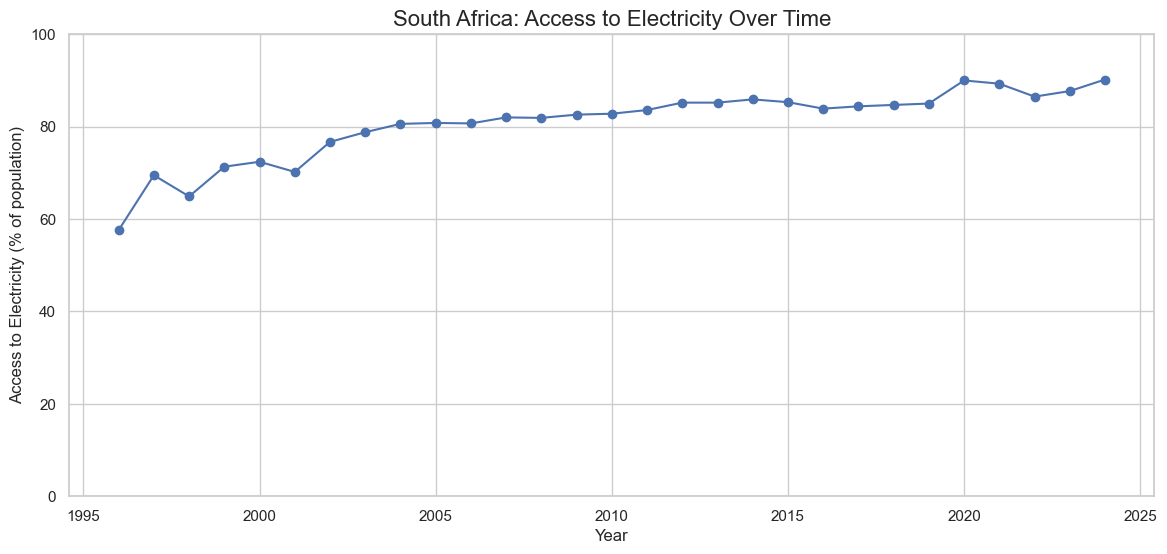

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    electricity_clean["Year"],
    electricity_clean["Electricity_Access"],
    marker="o"
)

plt.title(
    "South Africa: Access to Electricity Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Access to Electricity (% of population)")

plt.ylim(0, 100)

plt.show()

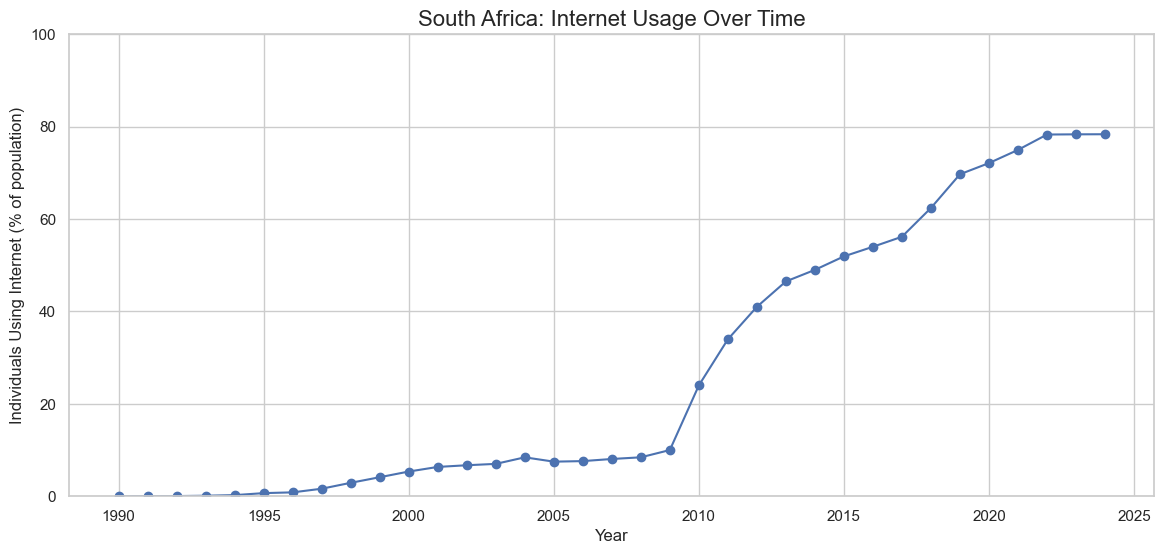

In [61]:
plt.figure(figsize=(14, 6))

plt.plot(
    internet_clean["Year"],
    internet_clean["Internet_Usage"],
    marker="o"
)

plt.title(
    "South Africa: Internet Usage Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Individuals Using Internet (% of population)")

plt.ylim(0, 100)

plt.show()

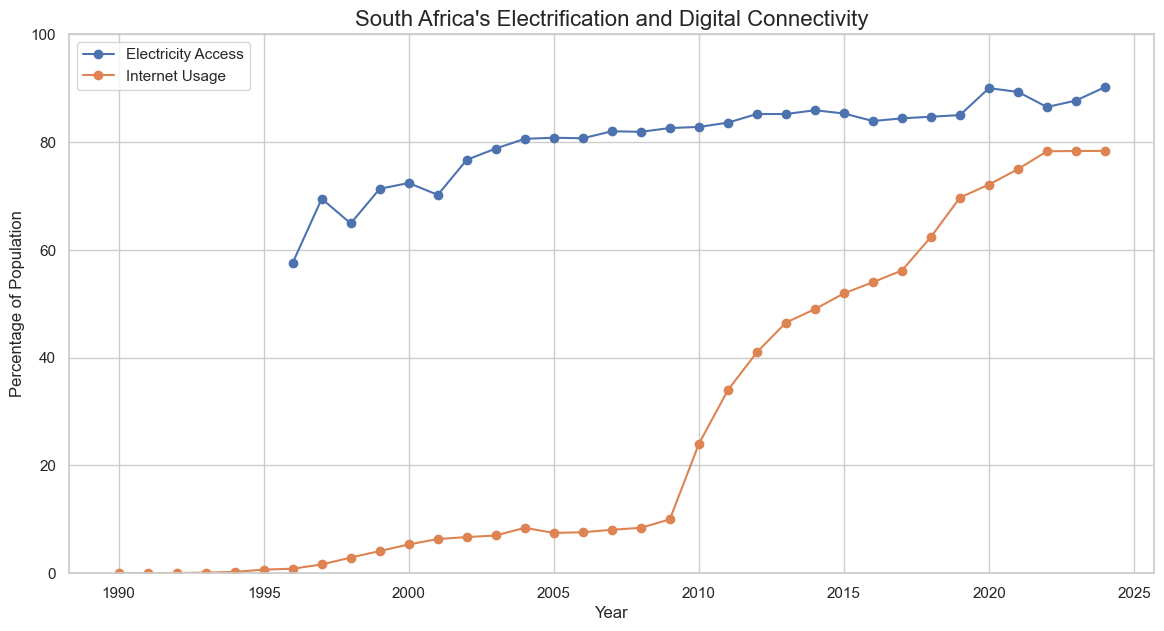

In [62]:
plt.figure(figsize=(14, 7))

plt.plot(
    south_africa["Year"],
    south_africa["Electricity_Access"],
    marker="o",
    label="Electricity Access"
)

plt.plot(
    south_africa["Year"],
    south_africa["Internet_Usage"],
    marker="o",
    label="Internet Usage"
)

plt.title(
    "South Africa's Electrification and Digital Connectivity",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Percentage of Population")

plt.ylim(0, 100)

plt.legend()

plt.show()

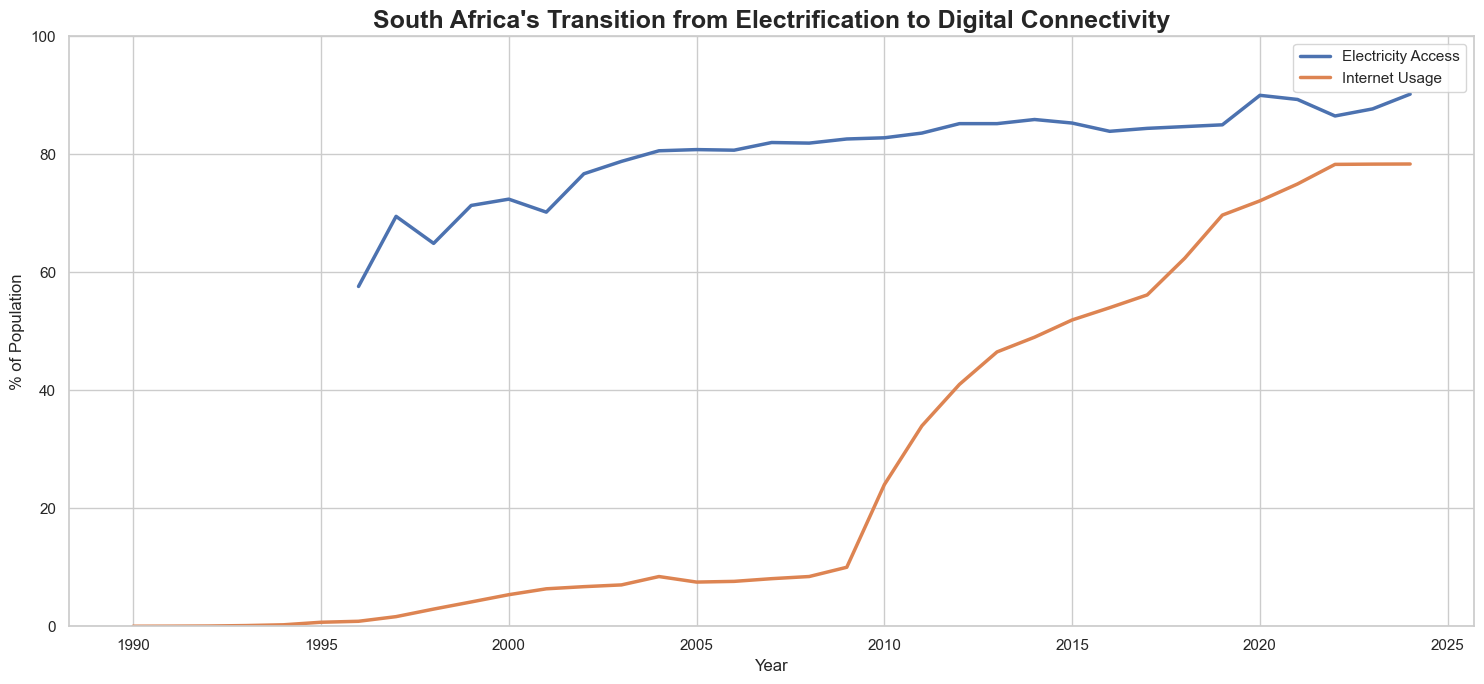

In [63]:
plt.figure(figsize=(15, 7))

plt.plot(
    south_africa["Year"],
    south_africa["Electricity_Access"],
    linewidth=2.5,
    label="Electricity Access"
)

plt.plot(
    south_africa["Year"],
    south_africa["Internet_Usage"],
    linewidth=2.5,
    label="Internet Usage"
)

plt.title(
    "South Africa's Transition from Electrification to Digital Connectivity",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("% of Population")

plt.ylim(0, 100)

plt.legend()

plt.tight_layout()

plt.show()

In [10]:
import numpy as np

# Electricity access data
electricity_access = np.array([
    # put ALL electricity access values here
])

# Internet usage data
internet_usage = np.array([
    # put ALL internet usage values here
])

print("Electricity Access:")
print(electricity_access)

print("\nInternet Usage:")
print(internet_usage)

Electricity Access:
[]

Internet Usage:
[]


In [15]:
import numpy as np

# Electricity Access data
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0,
    100.0, 100.0, 100.0, 100.0, 100.0,
    100.0, 100.0, 100.0, 100.0, 93.4,
    100.0, 100.0, 100.0, 100.0, 100.0,
    100.0, 100.0, 100.0, 100.0, 99.9,
    100.0, 100.0
])

# Remove missing values
electricity_clean = electricity_access[~np.isnan(electricity_access)]

# Calculate numerical statistics
electricity_mean = np.mean(electricity_clean)
electricity_median = np.median(electricity_clean)
electricity_min = np.min(electricity_clean)
electricity_max = np.max(electricity_clean)
electricity_std = np.std(electricity_clean)

# Display results
print("ELECTRICITY ACCESS ANALYSIS")
print("---------------------------")
print("Number of values:", len(electricity_clean))
print("Mean:", round(electricity_mean, 2), "%")
print("Median:", round(electricity_median, 2), "%")
print("Minimum:", round(electricity_min, 2), "%")
print("Maximum:", round(electricity_max, 2), "%")


ELECTRICITY ACCESS ANALYSIS
---------------------------
Number of values: 32
Mean: 99.46 %
Median: 100.0 %
Minimum: 91.7 %
Maximum: 100.0 %


In [16]:
import numpy as np

# Internet Usage data
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Calculate statistics
internet_mean = np.mean(internet_usage)
internet_median = np.median(internet_usage)
internet_min = np.min(internet_usage)
internet_max = np.max(internet_usage)
internet_std = np.std(internet_usage)

# Display results
print("INTERNET USAGE ANALYSIS")
print("-----------------------")
print("Number of values:", len(internet_usage))
print("Mean:", round(internet_mean, 2), "%")
print("Median:", round(internet_median, 2), "%")
print("Minimum:", round(internet_min, 2), "%")
print("Maximum:", round(internet_max, 2), "%")


INTERNET USAGE ANALYSIS
-----------------------
Number of values: 10
Mean: 32.75 %
Median: 32.75 %
Minimum: 10.0 %
Maximum: 55.5 %


In [19]:
import numpy as np

# Electricity Access
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Internet Usage
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

In [20]:
# Reshape Electricity Access
electricity_reshaped = electricity_access.reshape(2, 5)

# Reshape Internet Usage
internet_reshaped = internet_usage.reshape(2, 5)

print("ELECTRICITY ACCESS")
print(electricity_reshaped)

print("\nINTERNET USAGE")
print(internet_reshaped)

ELECTRICITY ACCESS
[[100.        99.153656  99.197128  99.239914 100.      ]
 [100.       100.       100.        91.7      100.      ]]

INTERNET USAGE
[[10.  15.5 20.  25.5 30. ]
 [35.5 40.  45.5 50.  55.5]]


In [21]:
# Row means
electricity_row_mean = np.mean(electricity_reshaped, axis=1)
internet_row_mean = np.mean(internet_reshaped, axis=1)

print("Electricity Access row means:")
print(electricity_row_mean)

print("\nInternet Usage row means:")
print(internet_row_mean)

Electricity Access row means:
[99.5181396 98.34     ]

Internet Usage row means:
[20.2 45.3]


In [22]:
# Column means
electricity_column_mean = np.mean(electricity_reshaped, axis=0)
internet_column_mean = np.mean(internet_reshaped, axis=0)

print("Electricity Access column means:")
print(electricity_column_mean)

print("\nInternet Usage column means:")
print(internet_column_mean)

Electricity Access column means:
[100.        99.576828  99.598564  95.469957 100.      ]

Internet Usage column means:
[22.75 27.75 32.75 37.75 42.75]


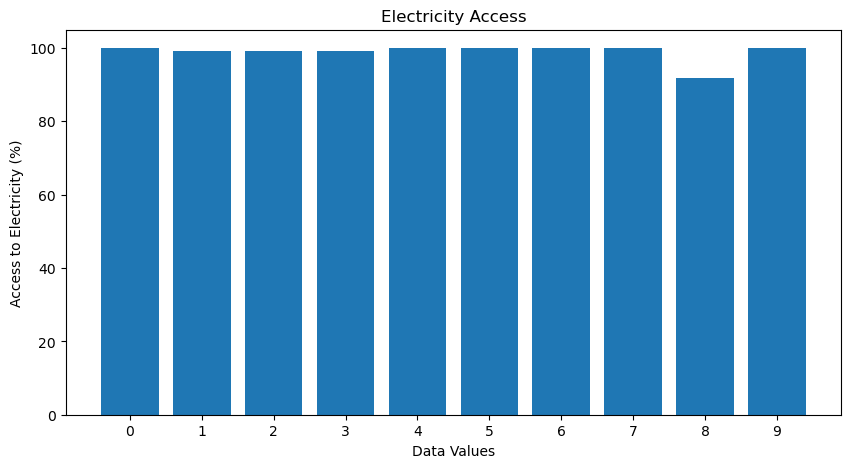

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Electricity Access data
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Create bar chart
plt.figure(figsize=(10, 5))

plt.bar(range(len(electricity_access)), electricity_access)

plt.title("Electricity Access")
plt.xlabel("Data Values")
plt.ylabel("Access to Electricity (%)")

plt.xticks(range(len(electricity_access)))

plt.show()

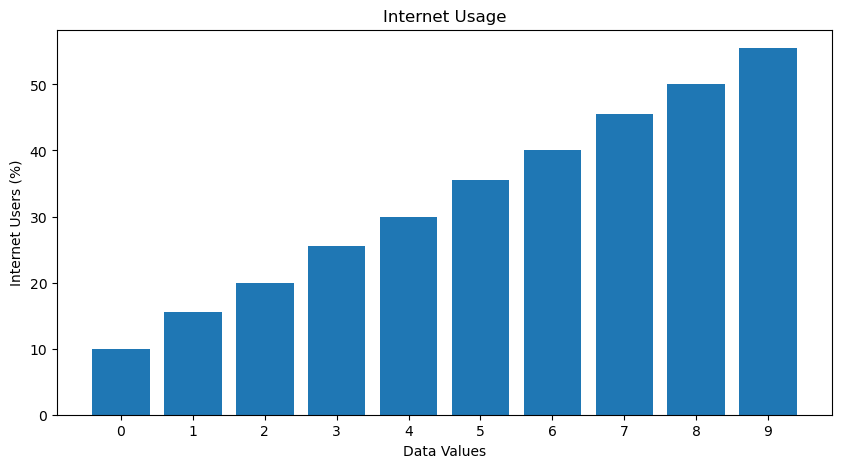

In [24]:
# Internet Usage data
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create bar chart
plt.figure(figsize=(10, 5))

plt.bar(range(len(internet_usage)), internet_usage)

plt.title("Internet Usage")
plt.xlabel("Data Values")
plt.ylabel("Internet Users (%)")

plt.xticks(range(len(internet_usage)))

plt.show()

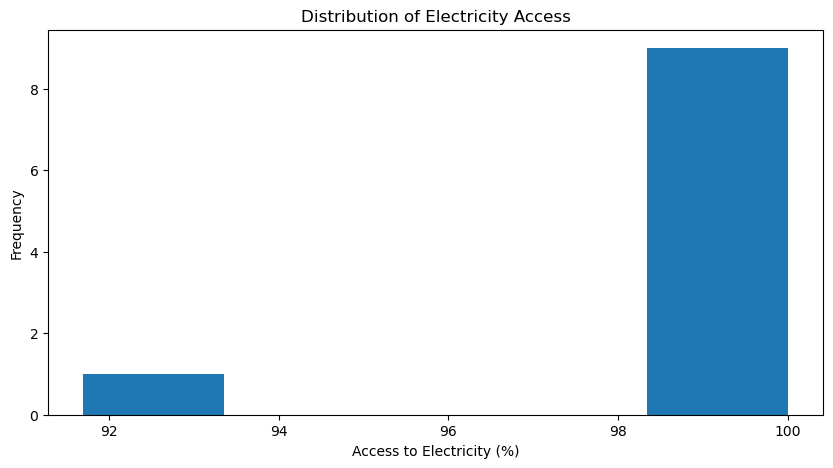

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Electricity Access data
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Create histogram
plt.figure(figsize=(10, 5))

plt.hist(electricity_access, bins=5)

plt.title("Distribution of Electricity Access")
plt.xlabel("Access to Electricity (%)")
plt.ylabel("Frequency")

plt.show()

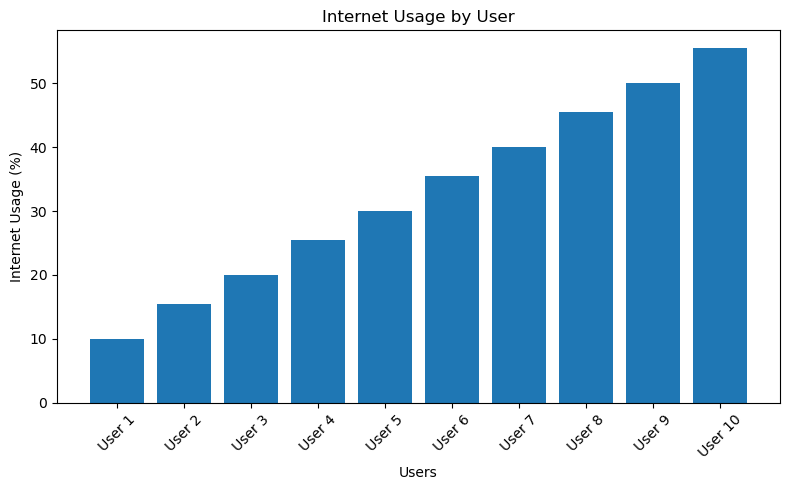

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Internet Usage data
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create bar chart
users = [
    "User 1", "User 2", "User 3", "User 4", "User 5",
    "User 6", "User 7", "User 8", "User 9", "User 10"
]

plt.figure(figsize=(8, 5))
plt.bar(users, internet_usage)

plt.title("Internet Usage by User")
plt.xlabel("Users")
plt.ylabel("Internet Usage (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

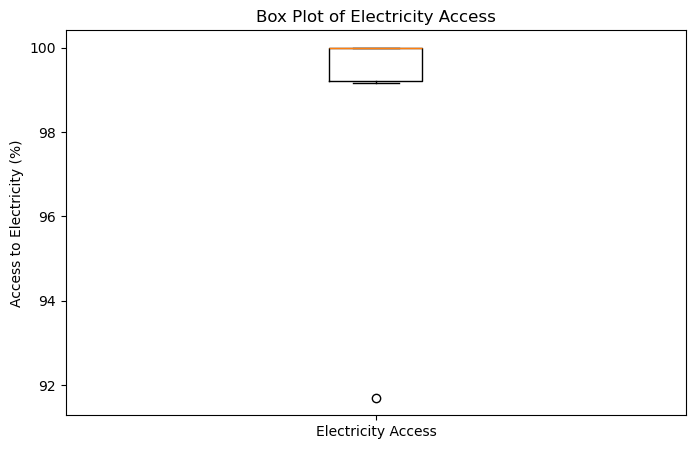

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Electricity Access data
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Create box plot
plt.figure(figsize=(8, 5))

plt.boxplot(electricity_access)

plt.title("Box Plot of Electricity Access")
plt.ylabel("Access to Electricity (%)")
plt.xticks([1], ["Electricity Access"])

plt.show()

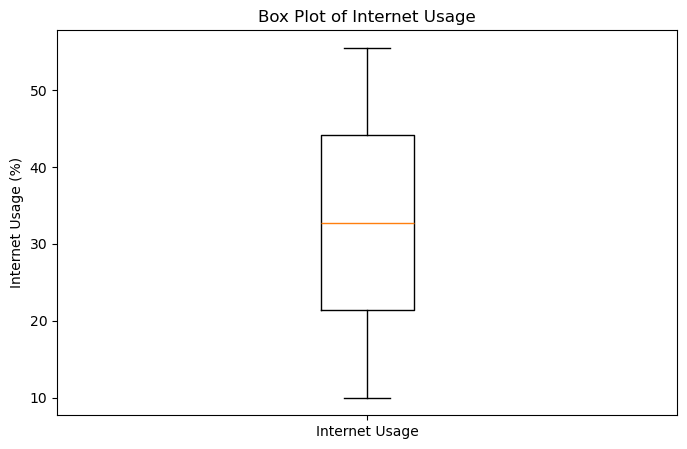

In [28]:
# Internet Usage data
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create box plot
plt.figure(figsize=(8, 5))

plt.boxplot(internet_usage)

plt.title("Box Plot of Internet Usage")
plt.ylabel("Internet Usage (%)")
plt.xticks([1], ["Internet Usage"])

plt.show()

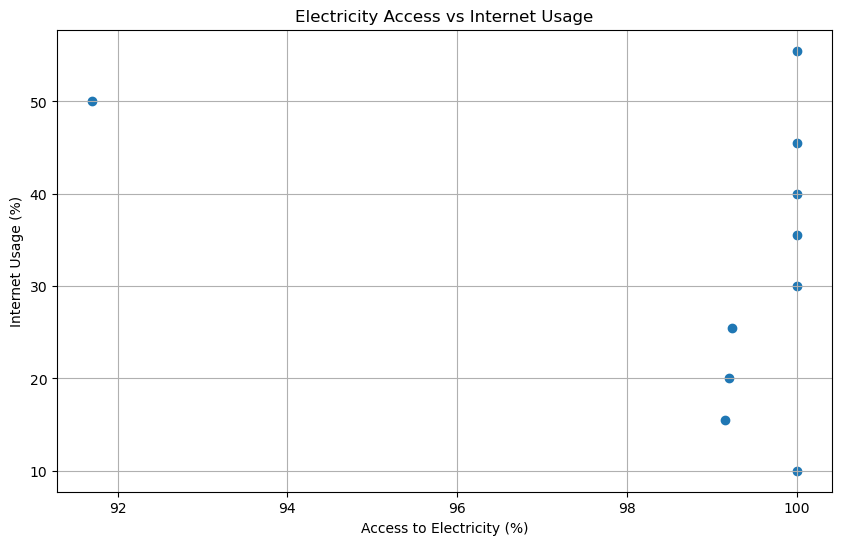

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Electricity Access (%)
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Internet Usage (%)
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(electricity_access, internet_usage)

plt.title("Electricity Access vs Internet Usage")
plt.xlabel("Access to Electricity (%)")
plt.ylabel("Internet Usage (%)")

plt.grid(True)

plt.show()

In [30]:
correlation = np.corrcoef(electricity_access, internet_usage)[0, 1]

print("Correlation between Electricity Access and Internet Usage:")
print(round(correlation, 2))

Correlation between Electricity Access and Internet Usage:
-0.32


In [32]:
import numpy as np

# Electricity Access
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Internet Usage
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Electricity statistics
electricity_mean = np.mean(electricity_access)
electricity_median = np.median(electricity_access)
electricity_min = np.min(electricity_access)
electricity_max = np.max(electricity_access)
electricity_std = np.std(electricity_access)

# Internet statistics
internet_mean = np.mean(internet_usage)
internet_median = np.median(internet_usage)
internet_min = np.min(internet_usage)
internet_max = np.max(internet_usage)
internet_std = np.std(internet_usage)

# Correlation
correlation = np.corrcoef(
    electricity_access,
    internet_usage
)[0, 1]

# Display results
print("======================================")
print("NUMERICAL ANALYSIS SUMMARY")
print("======================================")

print("\nELECTRICITY ACCESS")
print("Mean:", round(electricity_mean, 2), "%")
print("Median:", round(electricity_median, 2), "%")
print("Minimum:", round(electricity_min, 2), "%")
print("Maximum:", round(electricity_max, 2), "%")


print("\nINTERNET USAGE")
print("Mean:", round(internet_mean, 2), "%")
print("Median:", round(internet_median, 2), "%")
print("Minimum:", round(internet_min, 2), "%")
print("Maximum:", round(internet_max, 2), "%")


print("\nRELATIONSHIP")
print("Correlation:", round(correlation, 2))

NUMERICAL ANALYSIS SUMMARY

ELECTRICITY ACCESS
Mean: 98.93 %
Median: 100.0 %
Minimum: 91.7 %
Maximum: 100.0 %

INTERNET USAGE
Mean: 32.75 %
Median: 32.75 %
Minimum: 10.0 %
Maximum: 55.5 %

RELATIONSHIP
Correlation: -0.32


In [33]:
import numpy as np
import pandas as pd

# Electricity Access
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Internet Usage
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create results table
results = {
    "Statistic": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum",
        
    ],
    "Electricity Access (%)": [
        np.mean(electricity_access),
        np.median(electricity_access),
        np.min(electricity_access),
        np.max(electricity_access),
        
    ],
    "Internet Usage (%)": [
        np.mean(internet_usage),
        np.median(internet_usage),
        np.min(internet_usage),
        np.max(internet_usage),
        
    ]
}

results_table = pd.DataFrame(results)

# Round values
results_table["Electricity Access (%)"] = results_table["Electricity Access (%)"].round(2)
results_table["Internet Usage (%)"] = results_table["Internet Usage (%)"].round(2)

print(results_table)

  Statistic  Electricity Access (%)  Internet Usage (%)
0      Mean                   98.93               32.75
1    Median                  100.00               32.75
2   Minimum                   91.70               10.00
3   Maximum                  100.00               55.50


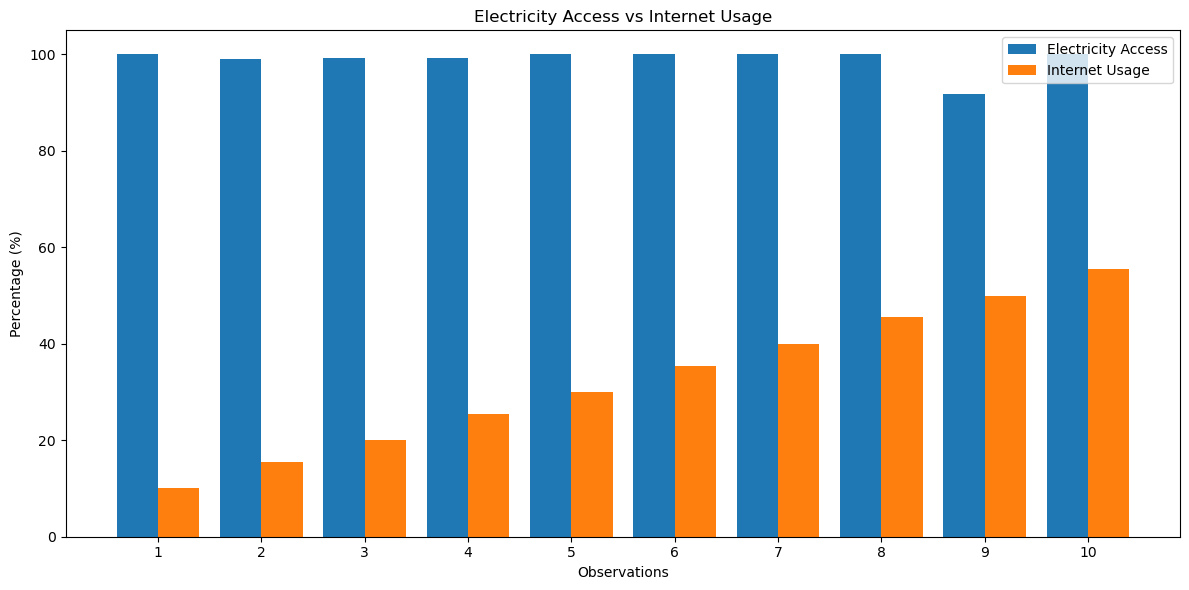

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Electricity Access (%)
electricity_access = np.array([
    100.0, 99.153656, 99.197128, 99.239914,
    100.0, 100.0, 100.0, 100.0, 91.7, 100.0
])

# Internet Usage (%)
internet_usage = np.array([
    10.0, 15.5, 20.0, 25.5, 30.0,
    35.5, 40.0, 45.5, 50.0, 55.5
])

# Create positions for the bars
x = np.arange(len(electricity_access))
width = 0.4

# Create the chart
plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    electricity_access,
    width,
    label="Electricity Access"
)

plt.bar(
    x + width/2,
    internet_usage,
    width,
    label="Internet Usage"
)

# Labels and title
plt.title("Electricity Access vs Internet Usage")
plt.xlabel("Observations")
plt.ylabel("Percentage (%)")

plt.xticks(x, range(1, len(electricity_access) + 1))

plt.legend()

plt.tight_layout()
plt.show()